& AUC & F1 & Prec & Recall & MCC & Acc & Brier & CM \\
STATIC & 0.773$\pm$0.034 & 0.268$\pm$0.014 & 0.157$\pm$0.009 & 0.915$\pm$0.053 & 0.265$\pm$0.026 & 0.597$\pm$0.026 & 0.156 & 
\cm{777.0}{589.0}{10.2}{109.8}{1366.0}{120.0} \\
STATIC+BiPadLSTM & 0.864$\pm$0.046 & 0.497$\pm$0.056 & 0.405$\pm$0.055 & 0.652$\pm$0.084 & 0.459$\pm$0.064 & 0.893$\pm$0.016 & 0.062 & 
\cm{1249.2}{116.8}{41.8}{78.2}{1366.0}{120.0} \\
STATIC+M2V & 0.907$\pm$0.025 & 0.519$\pm$0.055 & 0.413$\pm$0.058 & 0.712$\pm$0.093 & 0.488$\pm$0.063 & 0.893$\pm$0.019 & 0.063 & 
\cm{1241.0}{125.0}{34.6}{85.4}{1366.0}{120.0} \\
STATIC+Dipole & 0.885$\pm$0.038 & 0.520$\pm$0.047 & 0.430$\pm$0.056 & 0.673$\pm$0.102 & 0.485$\pm$0.055 & 0.899$\pm$0.016 & 0.062 & 
\cm{1255.8}{110.2}{39.2}{80.8}{1366.0}{120.0} \\
STATIC+CEHRBERT & 0.864$\pm$0.047 & 0.500$\pm$0.059 & 0.421$\pm$0.063 & 0.630$\pm$0.097 & 0.460$\pm$0.067 & 0.898$\pm$0.017 & 0.064 & 
\cm{1259.0}{107.0}{44.4}{75.6}{1366.0}{120.0} \\
STATIC+DOME & 0.928$\pm$0.023 & 0.496$\p

<>:62: SyntaxWarning: invalid escape sequence '\p'
<>:62: SyntaxWarning: invalid escape sequence '\p'
/var/folders/zz/9gtngyj552j0r83h82m32pvm0000gn/T/ipykernel_12180/4065799463.py:62: SyntaxWarning: invalid escape sequence '\p'
  print(f"{dfs[p][method].mean():.3f}$\pm${dfs[p][method].std():.3f} & ", end="")


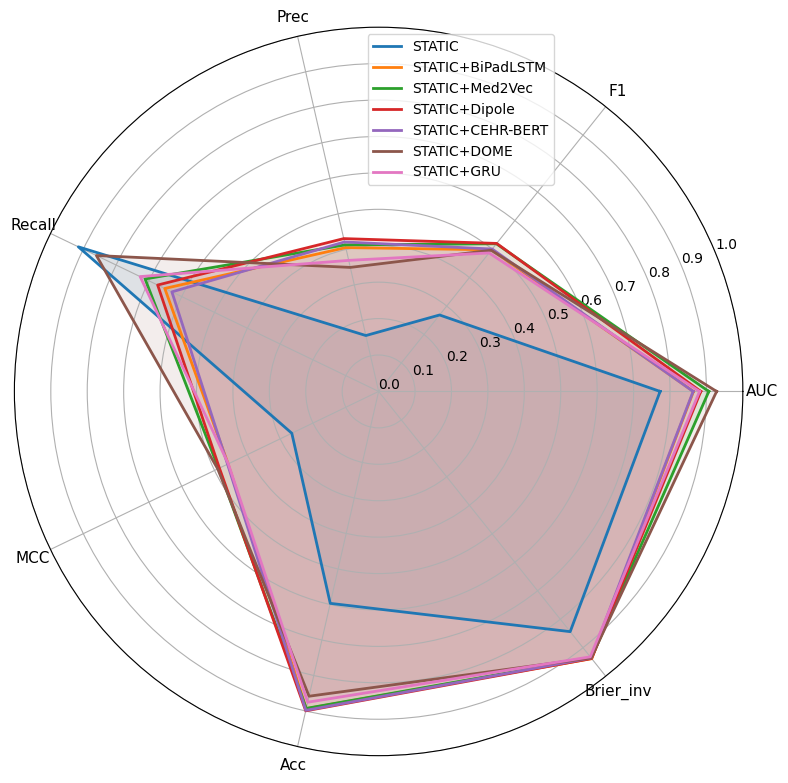

& AUC & F1 & Prec & Recall & MCC & Acc & Brier & CM \\
STATIC+BiPadLSTM & 0.749$\pm$0.094 & 0.402$\pm$0.099 & 0.396$\pm$0.096 & 0.426$\pm$0.136 & 0.353$\pm$0.107 & 0.900$\pm$0.022 & 0.073 & 
\cm{754.6}{47.4}{40.2}{29.8}{802.0}{70.0} \\
STATIC+M2V & 0.699$\pm$0.102 & 0.307$\pm$0.133 & 0.403$\pm$0.130 & 0.260$\pm$0.137 & 0.274$\pm$0.132 & 0.911$\pm$0.015 & 0.071 & 
\cm{775.8}{26.2}{51.8}{18.2}{802.0}{70.0} \\
STATIC+Dipole & 0.684$\pm$0.108 & 0.388$\pm$0.125 & 0.513$\pm$0.207 & 0.340$\pm$0.132 & 0.363$\pm$0.131 & 0.916$\pm$0.020 & 0.068 & 
\cm{774.8}{27.2}{46.2}{23.8}{802.0}{70.0} \\
STATIC+CEHRBERT & 0.766$\pm$0.103 & 0.372$\pm$0.146 & 0.390$\pm$0.179 & 0.369$\pm$0.142 & 0.322$\pm$0.161 & 0.900$\pm$0.026 & 0.075 & 
\cm{758.6}{43.4}{44.2}{25.8}{802.0}{70.0} \\
STATIC+DOME & 0.934$\pm$0.037 & 0.603$\pm$0.108 & 0.526$\pm$0.116 & 0.729$\pm$0.144 & 0.576$\pm$0.120 & 0.922$\pm$0.026 & 0.047 & 
\cm{753.0}{49.0}{19.0}{51.0}{802.0}{70.0} \\
STATIC+GRU & 0.641$\pm$0.074 & 0.270$\pm$0.119 & 0.469$

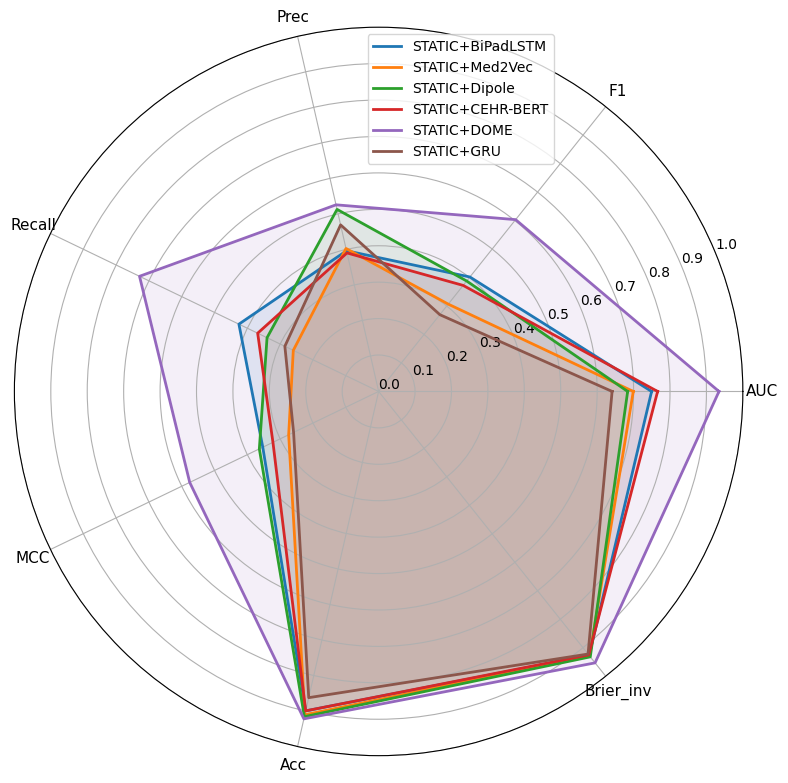

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
iter = 5
exclude_methods = [] #['STATIC+GRU-D']
metrics = ["AUC", "F1", "Prec", "Recall", "MCC", "Acc",]
tmetrics = metrics + ['Brier', 'CM']
results_dir = "results_calib"
dfs = {}
index_replacements = {'STATIC+M2V': 'STATIC+Med2Vec', 'STATIC+CEHRBERT': 'STATIC+CEHR-BERT'}

# Radar plot
def plot_radar(df, metrics):
    N = len(metrics)
    angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

    for idx, row in df.iterrows():
        values = row[metrics].tolist()
        values += values[:1]

        ax.plot(angles, values, linewidth=2, label=idx)
        ax.fill(angles, values, alpha=0.1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics, fontsize=11)

    ax.set_ylim(0, 1)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.set_yticklabels([f"{x:.1f}" for x in np.arange(0, 1.1, 0.1)])

    ax.grid(True)
    #plt.title("Model Comparison Radar Plot", pad=20)
    #ax.legend(loc='best')
    plt.legend(loc="upper right", bbox_to_anchor=(0.75, 1))
    plt.tight_layout()
    plt.show()
    return fig

for g in ['INA_icd', 'MIMIC']:
    for p in tmetrics:
        print(f"& {p} ", end='')
        dfs[p] = pd.read_csv(f"{results_dir}/resdata_{p}_{g}_ITER{iter}.csv", index_col=0)
        dfs[p].drop(columns=exclude_methods, inplace=True)
    print("\\\\")
    dfm = pd.DataFrame(columns = tmetrics, index = dfs[p].columns)
    dfm.index.name = "Model"
    for method in dfs[p].columns:
        print(f"{method} & ", end='')
        values = []
        for p in tmetrics:
            if p == "CM":
                cm = dfs[p][method].apply(lambda x: np.array(eval(x))).sum() / 5
                values += [cm]
                print(f"\\cm{{{cm[0][0]}}}{{{cm[0][1]}}}{{{cm[1][0]}}}{{{cm[1][1]}}}" + f"{{{float(cm[0][0])+float(cm[0][1])}}}{{{float(cm[1][0])+float(cm[1][1])}}} \\\\")
            elif p == 'Brier':
                print(f"{dfs[p][method].mean():.3f} & ", end="\n")
                values += [1 - dfs[p][method].mean()]
            else:
                print(f"{dfs[p][method].mean():.3f}$\pm${dfs[p][method].std():.3f} & ", end="")
                values += [dfs[p][method].mean()]
        dfm.loc[method] = values
    print()
    dfm.rename(columns={"Brier": "Brier_inv"}, index=index_replacements, inplace=True)
    fig = plot_radar(dfm,metrics + ['Brier_inv'])
    fig.savefig(f"figures/{g}_radar.png")

In [ ]:
dfm1 = dfm.rename(index={'STATIC+M2V': 'STATIC+Med2Vec', 'STATIC+CEHRBERT': 'STATIC+CEHR-BERT'})
dfm1

,AUC,F1,Prec,Recall,MCC,Acc,Brier_inv,CM
Model,,,,,,,,
STATIC+BiPadLSTM,0.749425,0.401898,0.396164,0.425714,0.353005,0.899547,0.927093,"[[754.6, 47.4], [40.2, 29.8]]"
STATIC+Med2Vec,0.69918,0.306563,0.402592,0.26,0.27413,0.910535,0.92884,"[[775.8, 26.2], [51.8, 18.2]]"
STATIC+Dipole,0.683723,0.387749,0.512642,0.34,0.363496,0.915845,0.932028,"[[774.8, 27.2], [46.2, 23.8]]"
STATIC+CEHR-BERT,0.765969,0.372298,0.389983,0.368571,0.322031,0.899563,0.925229,"[[758.6, 43.4], [44.2, 25.8]]"
STATIC+DOME,0.934468,0.603281,0.525542,0.728571,0.575631,0.922048,0.953118,"[[753.0, 49.0], [19.0, 51.0]]"
STATIC+GRU,0.640988,0.26957,0.468996,0.285714,0.259095,0.862363,0.922154,"[[732.0, 70.0], [50.0, 20.0]]"


## Calibration Curves

In [20]:
methods

NameError: name 'methods' is not defined

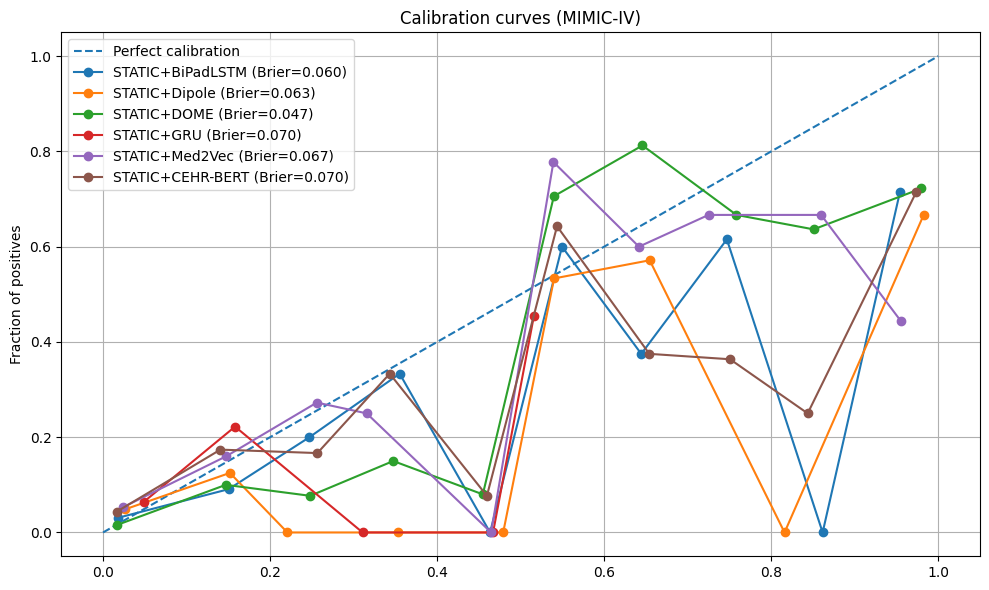

In [ ]:
from scripts.plotting import plot_calibration
import pickle
dataset = "MIMIC"
iter = 1
methods = [['STATIC', 'BiPadLSTM'], 
                    ['STATIC', 'M2V'],
                    ['STATIC', 'Dipole'],
                    ['STATIC', 'CEHRBERT'],
                    ['STATIC', 'DOME'],
                    ['STATIC', 'GRU'],
                    ]
prob_pred = {"+".join(m): [] for m in methods}
prob_true = {"+".join(m): [] for m in methods}
all_runs = {"+".join(m): ([], []) for m in methods}
for m in methods:
    with open(f"{results_dir}/results_{dataset}_{"_".join(m)}_ITER{iter}.pkl", "rb") as f:   
        results = pickle.load(f)
    prob_pred["+".join(m)] += list(results['calibration_prob_pred'])
    prob_true["+".join(m)] += list(results['calibration_prob_true'])
    all_runs["+".join(m)] = (all_runs["+".join(m)][0] + list(results['y_true_oof']),
                                all_runs["+".join(m)][1] +  list(results['y_prob_oof']))
prob_pred = {k: v for k, v in prob_pred.items() if k != 'STATIC'}
prob_true = {k: v for k, v in prob_true.items() if k != 'STATIC'}
all_runs = {k: v for k, v in all_runs.items() if k != 'STATIC'}
prob_pred['STATIC+Med2Vec'] = prob_pred.pop('STATIC+M2V')
prob_true['STATIC+Med2Vec'] = prob_true.pop('STATIC+M2V')
prob_pred['STATIC+CEHR-BERT'] = prob_pred.pop('STATIC+CEHRBERT')
prob_true['STATIC+CEHR-BERT'] = prob_true.pop('STATIC+CEHRBERT')
all_runs['STATIC+Med2Vec'] = all_runs.pop('STATIC+M2V')
all_runs['STATIC+CEHR-BERT'] = all_runs.pop('STATIC+CEHRBERT')
fig = plot_calibration(prob_pred, prob_true,all_runs,title=f"Calibration curves ({dataset})")
fig.savefig(f"figures/caliba_curve_{dataset}_ITER{iter}.png")